In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_classification
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.cluster import KMeans
from scipy.spatial import Voronoi, voronoi_plot_2d
from matplotlib.patches import Patch
from matplotlib import cm

In [17]:
def evaluate_clustering(data_points, centroids, n_clusters, ax=None, title_suffix=''):
    if ax is None:
        ax = plt.gca()
    
    silhouette_avg = silhouette_score(data_points, centroids)
    sample_silhouette_values = silhouette_samples(data_points, centroids)

    unique_labels = np.unique(centroids)
    colormap = cm.tab10
    color_dict = {centroids: colormap(float(centroids) / n_clusters) for centroids in unique_labels}
    y_lower = 10
    for i in unique_labels:
        ith_cluster_silhouette_values = sample_silhouette_values[centroids == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = color_dict[i]
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, ith_cluster_silhouette_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    
    ax.set_title(f'Silhouette Score for {title_suffix} \n' + 
                 f'Average Silhouette: {silhouette_avg:.2f}')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_xlim([-0.25, 1])

    #ax.set_yticks([])

    

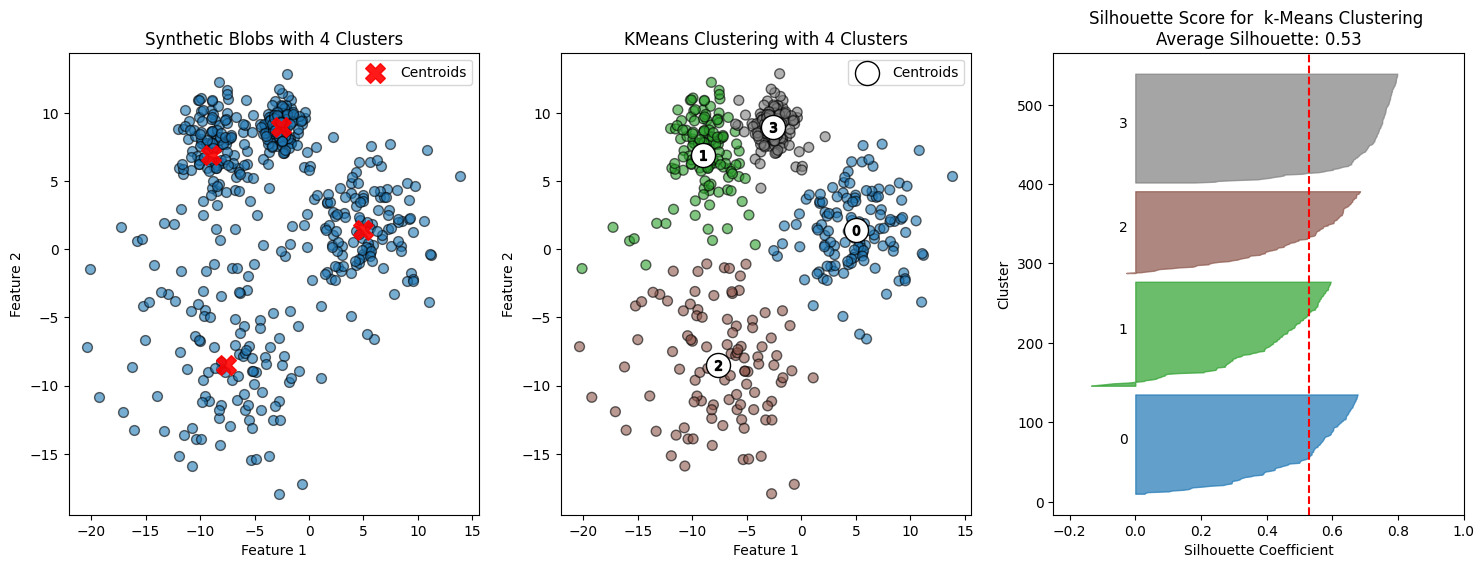

In [35]:
data_points, centroid = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=[1, 3, 5, 2], random_state=42)

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
y_kmeans = kmeans.fit_predict(data_points)

colormap = cm.tab10

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.scatter(data_points[:, 0], data_points[:, 1], s=50, alpha=0.6, edgecolor='k')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', alpha=0.9, label='Centroids')
plt.title(f'Synthetic Blobs with {n_clusters} Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

colors = colormap(y_kmeans.astype(float) / n_clusters)

plt.subplot(1, 3, 2)
plt.scatter(data_points[:, 0], data_points[:, 1], c=colors, s=50, alpha=0.6, edgecolor='k')

centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="o",
    c="white",
    alpha=1,
    s=300,
    ec="k",
    label="Centroids")

for i, c in enumerate(centers):
    plt.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

plt.title(f'KMeans Clustering with {n_clusters} Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

plt.subplot(1, 3, 3)
evaluate_clustering(data_points, y_kmeans, n_clusters, title_suffix=' k-Means Clustering')
plt.show()

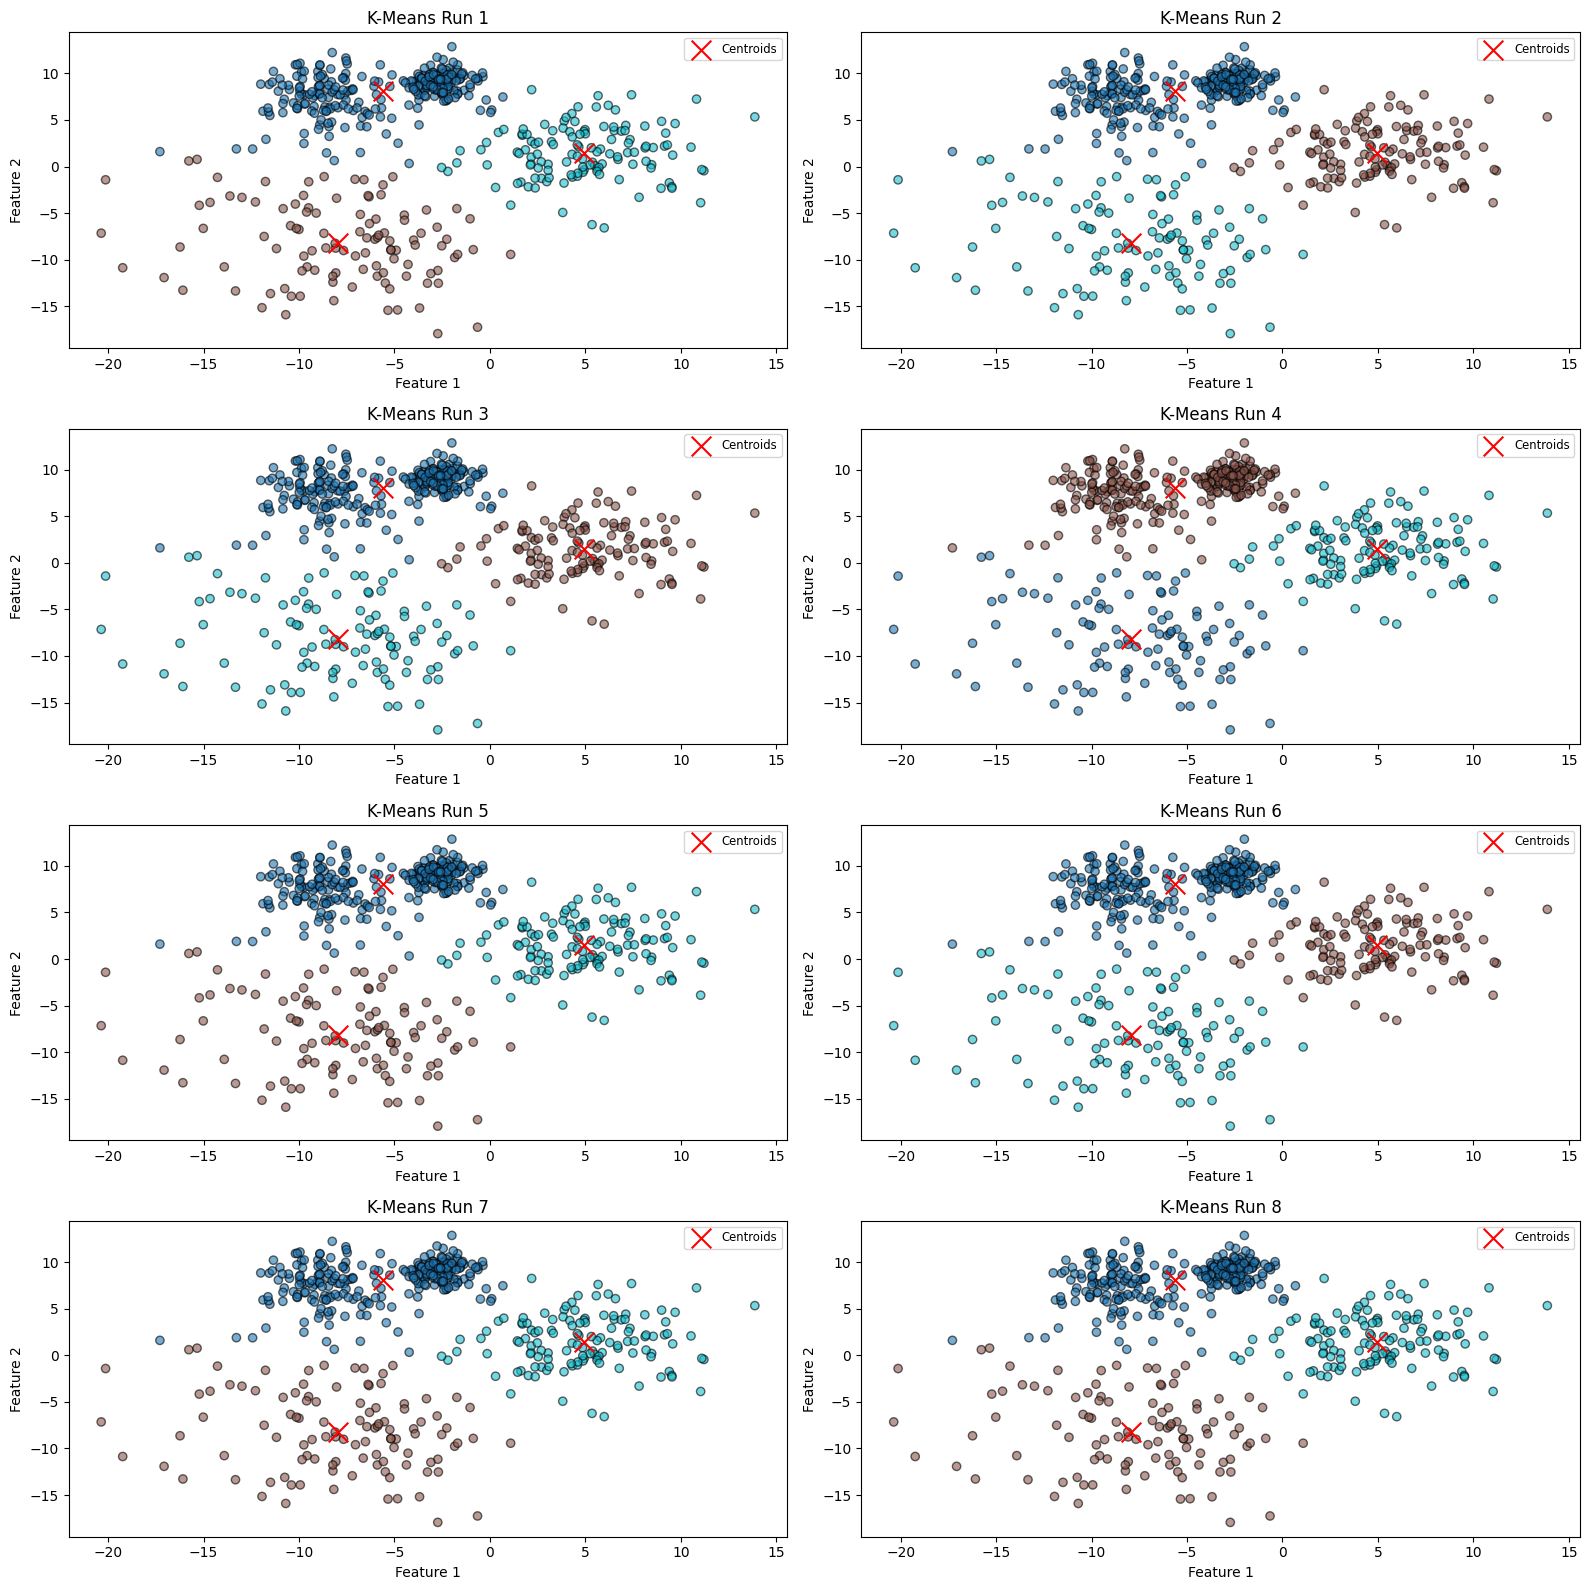

Run 1: Inertia=10480.57
Run 2: Inertia=10480.57
Run 3: Inertia=10480.57
Run 4: Inertia=10480.57
Run 5: Inertia=10480.57
Run 6: Inertia=10480.57
Run 7: Inertia=10480.57
Run 8: Inertia=10480.57


In [33]:
n_runs = 8
inertia_values = []

n_cols = 2 
n_rows = -(-n_runs // n_cols)
plt.figure(figsize=(16, 16))

for i in range(n_runs):
    kmeans = KMeans(n_clusters=3, random_state=None) 
    kmeans.fit(data_points)
    inertia_values.append(kmeans.inertia_)

    plt.subplot(n_rows, n_cols, i + 1)
    plt.scatter(data_points[:, 0], data_points[:, 1], c=kmeans.labels_, cmap='tab10', alpha=0.6, edgecolor='k')
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=200, marker='x', label='Centroids')
    plt.title(f'K-Means Run {i + 1}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend(loc='best', fontsize='small')

plt.tight_layout()
plt.show()

for i, inertia in enumerate(inertia_values, start=1):
    print(f'Run {i}: Inertia={inertia:.2f}')

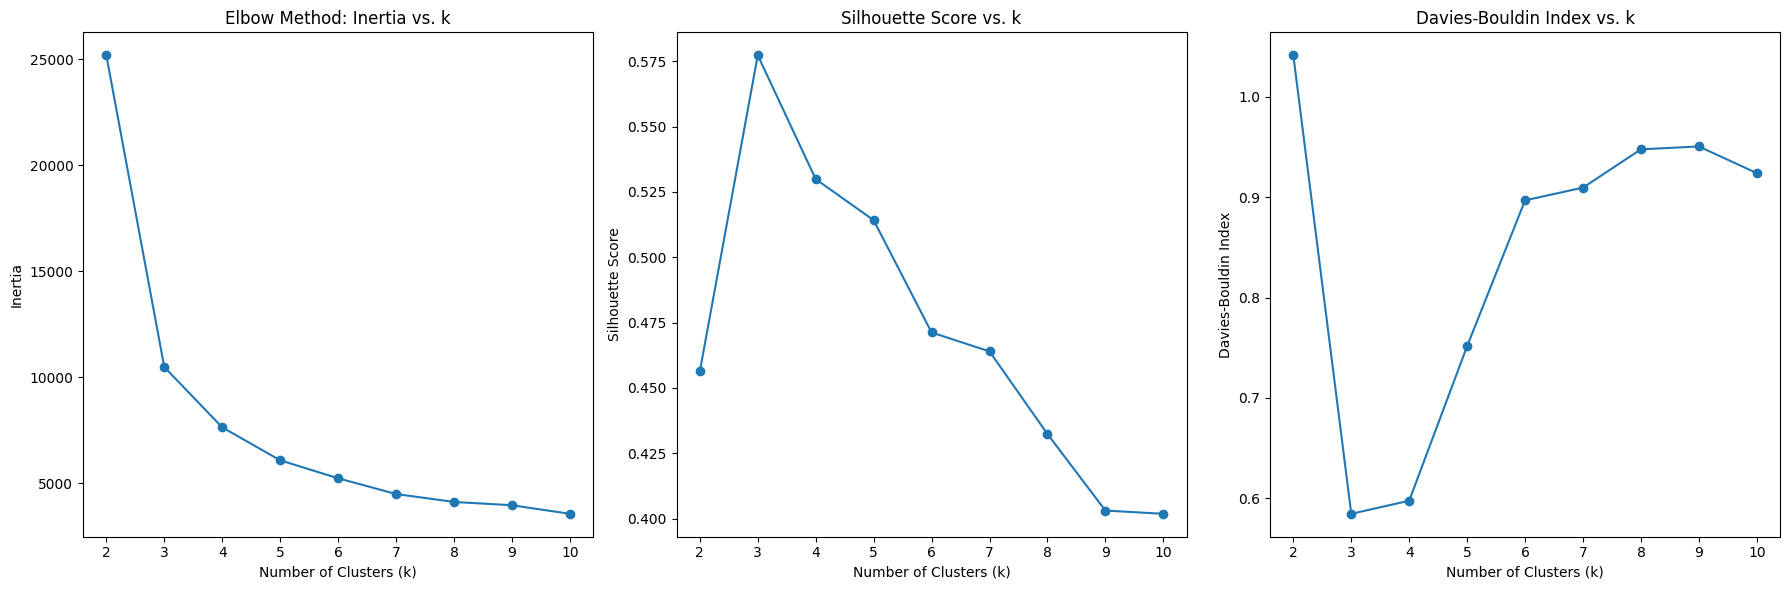

In [32]:
k_values = range(2, 11)

inertia_values = []
silhouette_scores = []
davies_bouldin_indices = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    y_kmeans = kmeans.fit_predict(data_points)
    
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(data_points, y_kmeans))
    davies_bouldin_indices.append(davies_bouldin_score(data_points, y_kmeans))

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(k_values, inertia_values, marker='o')
plt.title('Elbow Method: Inertia vs. k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1, 3, 2)
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score vs. k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.subplot(1, 3, 3)
plt.plot(k_values, davies_bouldin_indices, marker='o')
plt.title('Davies-Bouldin Index vs. k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Index')

plt.tight_layout()
plt.show()

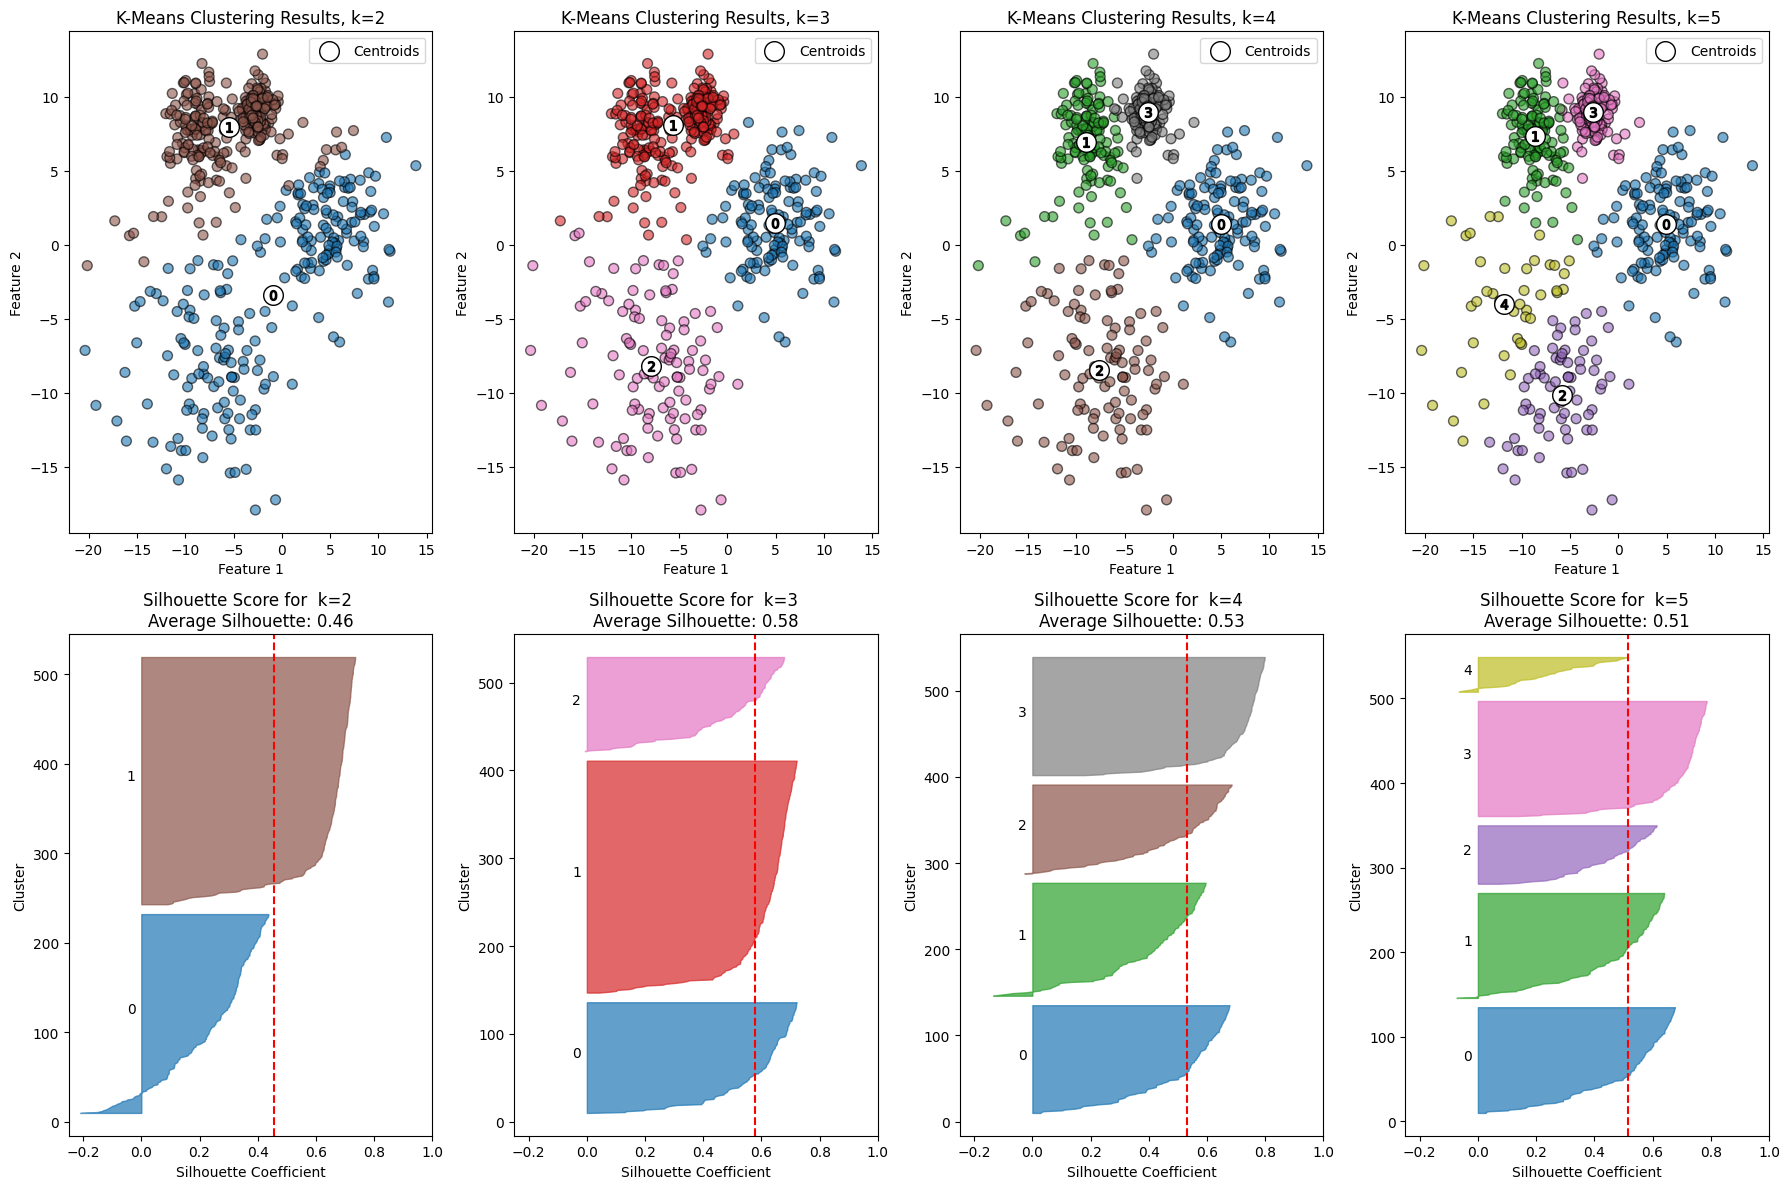

In [41]:
plt.figure(figsize=(18, 12))
colormap = cm.tab10

for i, k in enumerate([2, 3, 4, 5]):
    kmeans = KMeans(n_clusters=k, random_state=42) 
    y_kmeans = kmeans.fit_predict(data_points) 

    colors = colormap(y_kmeans.astype(float) / k)

    ax1 = plt.subplot(2, 4, i + 1)
    ax1.scatter(data_points[:, 0], data_points[:, 1], c=colors, s=50, alpha=0.6, edgecolor='k')
    
    centers = kmeans.cluster_centers_
    ax1.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
        label="Centroids"
    )

    for idx, c in enumerate(centers):
        ax1.scatter(c[0], c[1], marker=f"${idx}$", alpha=1, s=50, edgecolor="k")

    ax1.set_title(f'K-Means Clustering Results, k={k}')
    ax1.set_xlabel('Feature 1')
    ax1.set_ylabel('Feature 2')
    ax1.legend()

    # Silhouette plot for each k in the second row
    ax2 = plt.subplot(2, 4, i + 5)
    evaluate_clustering(data_points, y_kmeans, k, ax=ax2, title_suffix=f' k={k}')

plt.tight_layout()
plt.show()

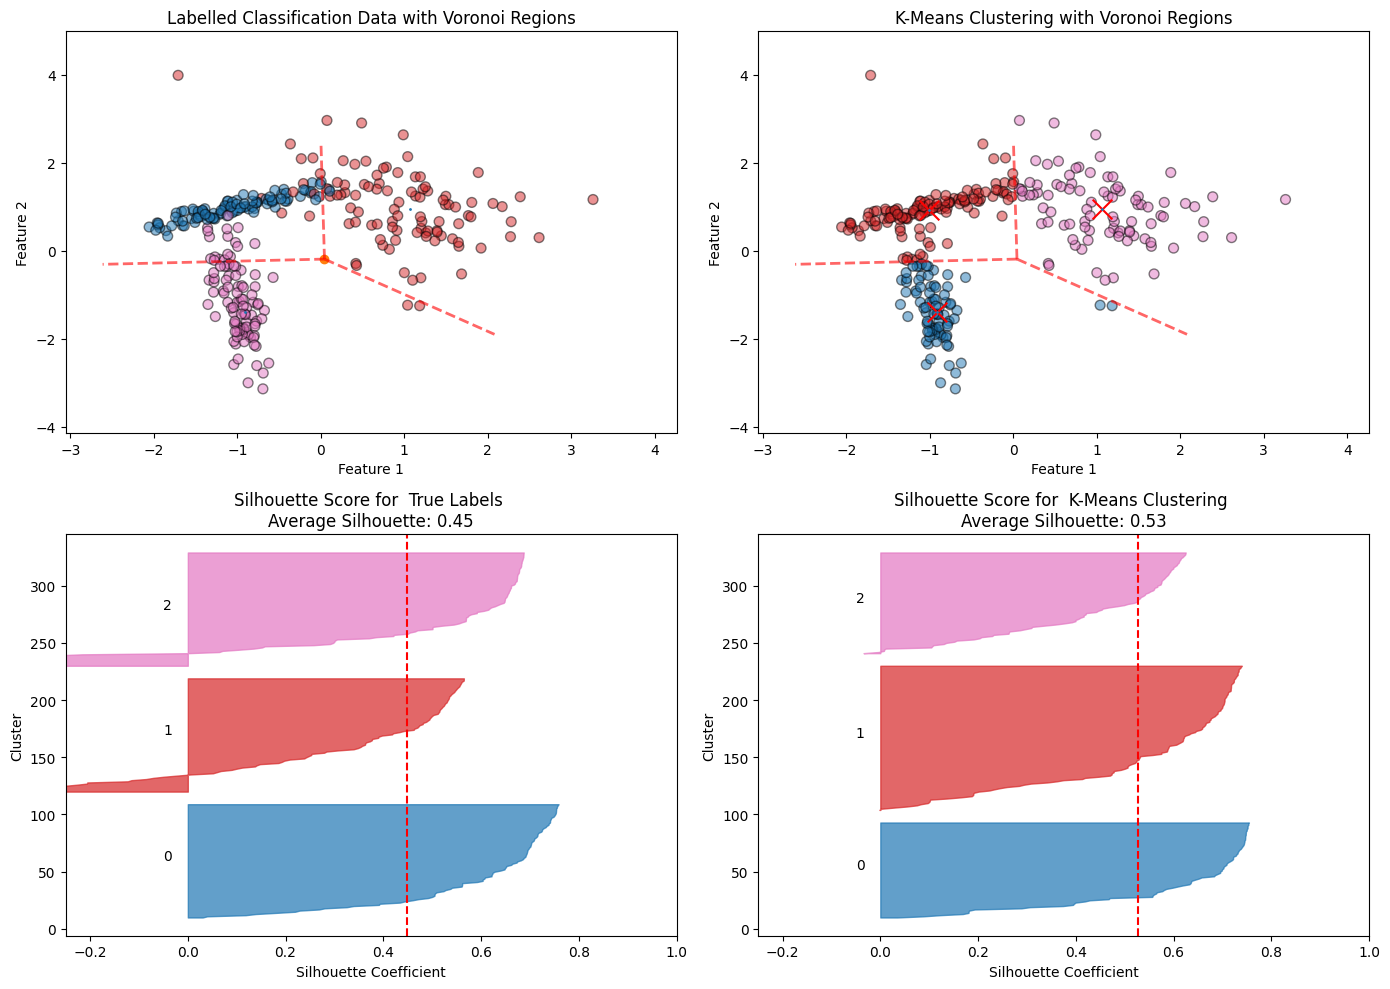

In [42]:
X, y_true = make_classification(n_samples=300, n_features=2, n_informative=2, n_redundant=0,
                                n_clusters_per_class=1, n_classes=3, random_state=42)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

vor = Voronoi(centroids)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

colormap = cm.tab10
colors_true = colormap(y_true.astype(float) / 3)
axes[0, 0].scatter(X[:, 0], X[:, 1], c=colors_true, s=50, alpha=0.5, ec='k')
voronoi_plot_2d(vor, ax=axes[0, 0], show_vertices=True, line_colors='red', line_width=2, line_alpha=0.6, point_size=2)
axes[0, 0].set_title('Labelled Classification Data with Voronoi Regions')
axes[0, 0].set_xlabel('Feature 1')
axes[0, 0].set_ylabel('Feature 2')
axes[0, 0].set_xlim(x_min, x_max)
axes[0, 0].set_ylim(y_min, y_max)

evaluate_clustering(X, y_true, n_clusters=3, ax=axes[1, 0], title_suffix=' True Labels')

colors_kmeans = colormap(y_kmeans.astype(float) / 3)
axes[0, 1].scatter(X[:, 0], X[:, 1], c=colors_kmeans, s=50, alpha=0.5, ec='k')
axes[0, 1].scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='x', label='Centroids')
voronoi_plot_2d(vor, ax=axes[0, 1], show_vertices=False, line_colors='red', line_width=2, line_alpha=0.6, point_size=2)

axes[0, 1].set_title('K-Means Clustering with Voronoi Regions')
axes[0, 1].set_xlabel('Feature 1')
axes[0, 1].set_ylabel('Feature 2')
axes[0, 1].set_xlim(x_min, x_max)
axes[0, 1].set_ylim(y_min, y_max)

evaluate_clustering(X, y_kmeans, n_clusters=3, ax=axes[1, 1], title_suffix=' K-Means Clustering')

plt.tight_layout()
plt.show()